# Healthcare Analytics for Doctor Visits

This notebook analyses a healthcare dataset on doctor visits (5,190 records, 13 columns in the raw file).

The file does not come with a data dictionary, so this notebook only uses what can be seen in the data itself: column names, data types and value ranges.

## 1. Understanding Basic Structure of Dataset

In [1]:
# Importing Libraries for Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Importing Dataset
df = pd.read_csv(r"Healthcare_Analytics_for_Doctor_Visits.csv") # r to remove unicode error

In [3]:
# Checking top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
# Checking bottom 5 rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
# Analysing Shape of Dataset
print("Shape of Dataset : ")
print("(rows, columns) =>", df.shape)

Shape of Dataset : 
(rows, columns) => (5190, 13)


In [6]:
# Total no. of elements in the dataset
print("Total no. of Element :", df.size) # It also counts null value

Total no. of Element : 67470


In [7]:
# Analysing Columns
count = 1
print("Column Names :")
for i in df.columns:
    print("    ", count, i)
    count = count + 1

Column Names :
     1 Unnamed: 0
     2 visits
     3 gender
     4 age
     5 income
     6 illness
     7 reduced
     8 health
     9 private
     10 freepoor
     11 freerepat
     12 nchronic
     13 lchronic


In [8]:
# Analysing Datatypes of columns
df.dtypes

Unnamed: 0      int64
visits          int64
gender         object
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private        object
freepoor       object
freerepat      object
nchronic       object
lchronic       object
dtype: object

In [9]:
# Analysing indexes, columns, data-types of each column, memory at once
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


The first column has no name (`Unnamed: 0`). Let's check whether it is just a running row number.

In [10]:
# Is 'Unnamed: 0' simply 1, 2, 3 ... n ?
(df['Unnamed: 0'].values == np.arange(1, len(df) + 1)).all()

np.True_

Yes, it is only a row counter, so it carries no information about the patient. It is removed in Section 2, after the duplicate check.

## 2. Checking for Duplicates and deciding how to handle them

In [11]:
# Checking the duplicate rows (row-number column included)
df[df.duplicated()]

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic


No duplicates, but that is only because the row counter makes every row unique. Let's compare rows using the **actual data columns only**.

In [12]:
# Checking duplicates again, ignoring the row-number column
data_cols = [c for c in df.columns if c != 'Unnamed: 0']

print("Rows that repeat an earlier row   :", df.duplicated(subset=data_cols).sum())
print("Rows involved in any repetition   :", df.duplicated(subset=data_cols, keep=False).sum())
print("Share of dataset that is repeated : {:.1f}%".format(df.duplicated(subset=data_cols).mean() * 100))

Rows that repeat an earlier row   : 1320
Rows involved in any repetition   : 1894
Share of dataset that is repeated : 25.4%


In [13]:
# Which combinations of values repeat the most?
(df.groupby(data_cols).size()
   .sort_values(ascending=False)
   .head(5)
   .reset_index(name='times_repeated'))

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,times_repeated
0,0,male,0.22,0.75,0,0,0,no,no,no,no,no,18
1,0,female,0.72,0.25,1,0,0,no,no,yes,yes,no,17
2,0,male,0.22,0.90,0,0,0,no,no,no,no,no,17
3,0,female,0.22,0.65,0,0,0,yes,no,no,no,no,16
4,0,female,0.72,0.25,0,0,0,no,no,yes,no,no,14


**Decision: these rows are kept.**

- There is no patient ID, so we cannot tell whether two identical rows are the same person recorded twice or two different people.
- Most columns take very few distinct values (for example `age` has only 12 and `illness` only 6), so identical rows are expected by chance.
- Dropping them would remove about a quarter of the data and distort every count and average below.

Now the row-number column can be dropped, since it adds nothing.

In [14]:
# Dropping the row-number column
df.drop(columns='Unnamed: 0', inplace=True)

In [15]:
# Checking shape after removing
print("Shape of Dataset : ")
print("(rows, columns) =>", df.shape)

Shape of Dataset : 
(rows, columns) => (5190, 12)


## 3. Checking for NULL value and fix if needed

In [16]:
# Checking for null values in each column
print("NULL Values :")
df.isnull().sum()

NULL Values :


visits       0
gender       0
age          0
income       0
illness      0
reduced      0
health       0
private      0
freepoor     0
freerepat    0
nchronic     0
lchronic     0
dtype: int64

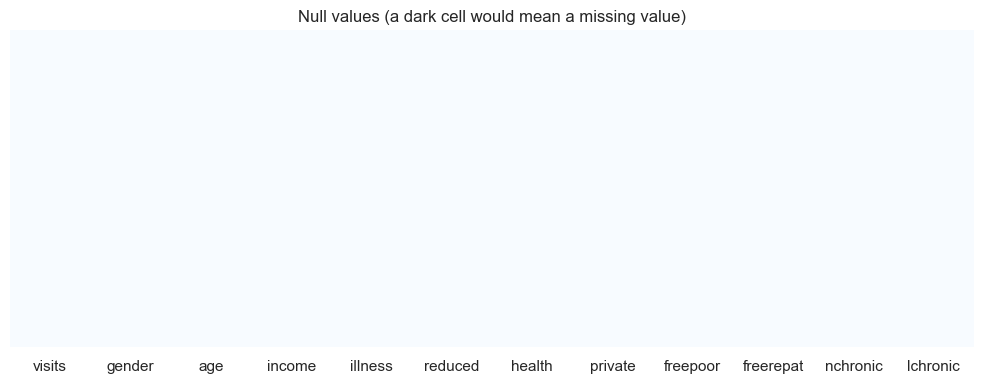

In [17]:
# Checking NULL values using heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Blues")
plt.title("Null values (a dark cell would mean a missing value)")
plt.tight_layout()
plt.show()

There are no missing values, so nothing needs to be filled or removed. Let's also sanity-check the value ranges.

In [18]:
# Statistical summary of the numeric columns (also reveals impossible values such as negatives)
df.describe().round(3)

,visits,age,income,illness,reduced,health
count,5190.000,5190.000,5190.000,5190.000,5190.000,5190.000
mean,0.302,0.406,0.583,1.432,0.862,1.218
std,0.798,0.205,0.369,1.384,2.888,2.124
min,0.000,0.190,0.000,0.000,0.000,0.000
25%,0.000,0.220,0.250,0.000,0.000,0.000
50%,0.000,0.320,0.550,1.000,0.000,0.000
75%,0.000,0.620,0.900,2.000,0.000,2.000
max,9.000,0.720,1.500,5.000,14.000,12.000


In [19]:
# Unique values of the yes/no columns
for col in df.select_dtypes(exclude='number').columns:
    print(col, "=>", sorted(df[col].unique()))

gender => ['female', 'male']
private => ['no', 'yes']
freepoor => ['no', 'yes']
freerepat => ['no', 'yes']
nchronic => ['no', 'yes']
lchronic => ['no', 'yes']


## 4. Solving Few Questions

**Q1) Which patient(s) made the highest number of doctor visits? Show their full records.**

In [20]:
# METHOD 1 =>
df['visits'].max()

9

In [21]:
df[df['visits'] == df['visits'].max()]

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
662,9,male,0.62,0.25,5,14,10,no,no,yes,no,yes


In [22]:
# Method 2 =>
max_visits = df['visits'].max()
df.query("visits == @max_visits")

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
662,9,male,0.62,0.25,5,14,10,no,no,yes,no,yes


**Q2) How many patients made 0, 1, 2 ... visits? What share of patients visited a doctor at least once?**

In [23]:
df['visits'].value_counts().sort_index()

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

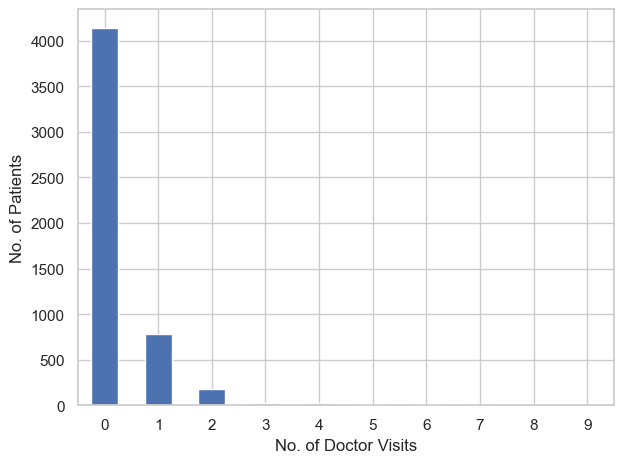

In [24]:
# Plotting no. of patients by number of visits using bar chart
df['visits'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("No. of Doctor Visits")
plt.ylabel("No. of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Share of patients with at least one visit
visited = (df['visits'] > 0).sum()
print("Patients with at least 1 visit :", visited, "out of", len(df))
print("Percentage                     : {:.1f}%".format(visited / len(df) * 100))

Patients with at least 1 visit : 1049 out of 5190
Percentage                     : 20.2%


**Q3) How many Male and Female patients are in the dataset?**

In [26]:
# Method 1
df.groupby('gender').gender.count()

gender
female    2702
male      2488
Name: gender, dtype: int64

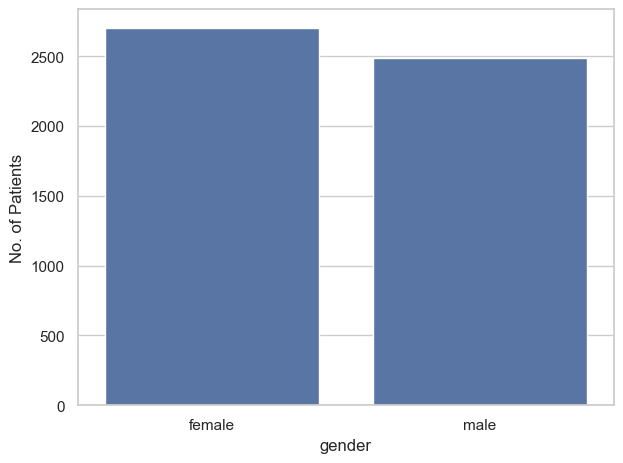

In [27]:
# Method 2
sns.countplot(x='gender', data=df)
plt.ylabel("No. of Patients")
plt.tight_layout()
plt.show()

**Q4) Show all the Female patients who visited the doctor at least once.**

In [28]:
df.head(2)

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no


In [29]:
df[(df['gender'] == 'female') & (df['visits'] >= 1)]

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
5,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,1,female,0.19,0.15,3,0,6,no,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...
1042,1,female,0.72,0.25,0,0,0,no,no,yes,no,no
1043,1,female,0.72,0.25,0,0,0,no,no,yes,no,no
1044,2,female,0.72,0.25,0,0,0,no,no,yes,no,no
1045,1,female,0.72,0.25,0,0,0,no,no,yes,no,yes


In [30]:
df[(df['gender'] == 'female') & (df['visits'] >= 1)].shape

(660, 12)

**Q5) Show only the 'income' of all patients who have private insurance and `lchronic` = yes.**

In [31]:
df[(df['private'] == 'yes') & (df['lchronic'] == 'yes')]['income']

29      0.25
80      0.45
147     1.10
167     0.45
187     0.06
        ... 
4758    1.50
4880    0.45
4911    1.50
5054    1.50
5155    0.25
Name: income, Length: 231, dtype: float64

**Q6) Show the Top 10 most common income values among the patients.**

In [32]:
df['income'].value_counts().head(10)

income
0.25    1195
0.90     589
0.55     467
0.35     462
0.65     455
0.75     441
0.45     400
1.10     361
0.15     249
1.50     215
Name: count, dtype: int64

**Q7) Show all the records where "gender is male and has private insurance" or "patient has `freepoor` = yes".**

In [33]:
df[((df['gender'] == 'male') & (df['private'] == 'yes')) | (df['freepoor'] == 'yes')]

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
9,1,male,0.19,0.15,1,0,0,yes,no,no,no,no
14,1,male,0.19,0.25,3,1,0,yes,no,no,yes,no
16,2,male,0.19,0.45,1,0,5,yes,no,no,no,no
22,1,male,0.19,0.45,2,2,0,yes,no,no,no,no
25,1,female,0.19,0.15,1,2,6,no,yes,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...
5128,0,male,0.72,1.50,1,0,0,yes,no,no,yes,no
5132,0,male,0.72,0.45,3,0,0,yes,no,no,yes,no
5151,0,male,0.72,0.90,1,0,0,yes,no,no,yes,no
5163,0,male,0.72,1.50,0,0,3,yes,no,no,no,no


**Q8) In how many records do patients have both `nchronic` = yes and `lchronic` = yes?**

In [34]:
# Method 1
df[(df['nchronic'] == 'yes') & (df['lchronic'] == 'yes')].shape

(0, 12)

In [35]:
# Method 2 => cross table shows all four combinations at once
pd.crosstab(df['nchronic'], df['lchronic'])

lchronic,no,yes
nchronic,,
no,2493,605
yes,2092,0


No record has both flags set to 'yes': 2,092 patients have only `nchronic`, 605 have only `lchronic` and 2,493 have neither. The two columns never overlap.

**Q9) What are the different values of `illness` recorded in the dataset?**

In [36]:
df["illness"].nunique() # df.illness.nunique()

6

In [37]:
np.sort(df.illness.unique())

array([0, 1, 2, 3, 4, 5])

**Q9.1) How many Female patients with private insurance visited the doctor at least once?**

In [38]:
df[(df['gender'] == 'female') & (df['private'] == 'yes') & (df['visits'] >= 1)].shape

(292, 12)

**Q9.2) How many patients with `lchronic` = yes have a `health` value above 5?**

In [39]:
df[(df['lchronic'] == 'yes') & (df['health'] > 5)].shape

(92, 12)

**Q10) What are the minimum, maximum, average and median values of every numeric column?**

In [40]:
df.select_dtypes(include='number').agg(['min', 'max', 'mean', 'median']).T.round(3)

,min,max,mean,median
visits,0.00,9.00,0.302,0.00
age,0.19,0.72,0.406,0.32
income,0.00,1.50,0.583,0.55
illness,0.00,5.00,1.432,1.00
reduced,0.00,14.00,0.862,0.00
health,0.00,12.00,1.218,0.00


**Q11) Which gender has the highest average number of doctor visits?**

In [41]:
df.groupby('gender')['visits'].mean().round(3)

gender
female    0.362
male      0.236
Name: visits, dtype: float64

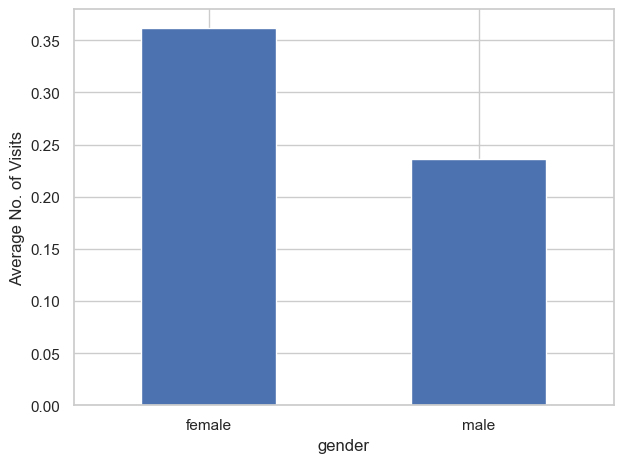

In [42]:
df.groupby('gender')['visits'].mean().plot(kind='bar')
plt.ylabel("Average No. of Visits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Q11.1) How do the average visits differ between patients with 'yes' and 'no' in each yes/no column?**

In [43]:
flag_cols = ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

rows = []
for c in flag_cols:
    rows.append({
        'Column': c,
        'Patients (yes)': (df[c] == 'yes').sum(),
        'Avg visits (yes)': df.loc[df[c] == 'yes', 'visits'].mean(),
        'Avg visits (no)': df.loc[df[c] == 'no', 'visits'].mean(),
    })

flag_summary = pd.DataFrame(rows).set_index('Column').round(3)
flag_summary

,Patients (yes),Avg visits (yes),Avg visits (no)
Column,,,
private,2298,0.295,0.307
freepoor,222,0.158,0.308
freerepat,1091,0.467,0.258
nchronic,2092,0.346,0.272
lchronic,605,0.603,0.262


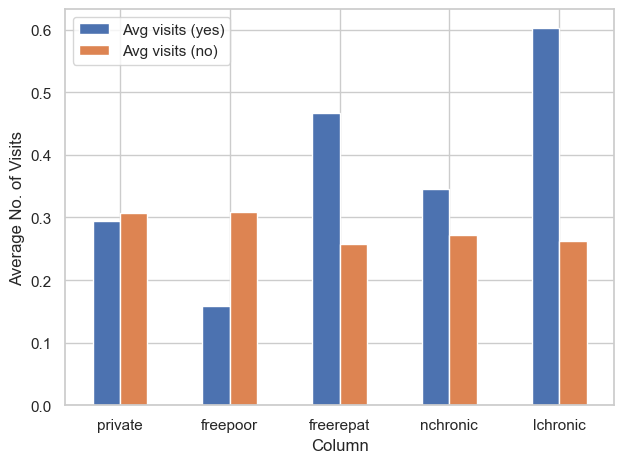

In [44]:
flag_summary[['Avg visits (yes)', 'Avg visits (no)']].plot(kind='bar')
plt.ylabel("Average No. of Visits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Q12) How can we sort the dataset by number of visits?**

In [45]:
df.head(2)

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no


In [46]:
df.sort_values(by='visits', ascending=False).head(5) # remove ascending = False for ascending order

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
662,9,male,0.62,0.25,5,14,10,no,no,yes,no,yes
742,8,male,0.67,0.25,2,14,5,no,no,yes,yes,no
598,8,male,0.57,0.01,1,9,4,no,no,no,no,no
47,8,female,0.19,0.25,2,7,0,no,no,no,no,yes
629,8,female,0.62,1.50,1,14,1,yes,no,no,no,no


In [47]:
# Sorting by more than one column: most visits first, and for equal visits the lowest income first
df.sort_values(by=['visits', 'income'], ascending=[False, True]).head(5)

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
662,9,male,0.62,0.25,5,14,10,no,no,yes,no,yes
598,8,male,0.57,0.01,1,9,4,no,no,no,no,no
47,8,female,0.19,0.25,2,7,0,no,no,no,no,yes
524,8,male,0.52,0.25,5,14,7,no,no,yes,no,yes
742,8,male,0.67,0.25,2,14,5,no,no,yes,yes,no


**Q13) Find all the instances where (gender is female and `lchronic` = yes) or (gender is male and `nchronic` = yes).**

In [48]:
df.head(2)

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no


In [49]:
df[(df['gender'] == 'female') & (df['lchronic'] == 'yes')].shape

(340, 12)

In [50]:
df[(df['gender'] == 'male') & (df['nchronic'] == 'yes')].shape

(807, 12)

In [51]:
df[(df['gender'] == 'female') & (df['lchronic'] == 'yes') | (df['gender'] == 'male') & (df['nchronic'] == 'yes')]

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
12,2,male,0.19,0.55,3,13,1,no,no,no,yes,no
13,1,male,0.19,0.45,4,7,6,no,no,no,yes,no
14,1,male,0.19,0.25,3,1,0,yes,no,no,yes,no
24,1,female,0.19,0.25,2,14,11,no,no,yes,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
5145,0,male,0.72,0.25,1,0,0,no,no,yes,yes,no
5149,0,female,0.72,0.25,2,0,0,no,no,yes,no,yes
5151,0,male,0.72,0.90,1,0,0,yes,no,no,yes,no
5154,0,female,0.72,0.25,1,0,0,no,no,yes,no,yes


## 5. Further Analytics

**Q14) How are the numeric columns distributed?**

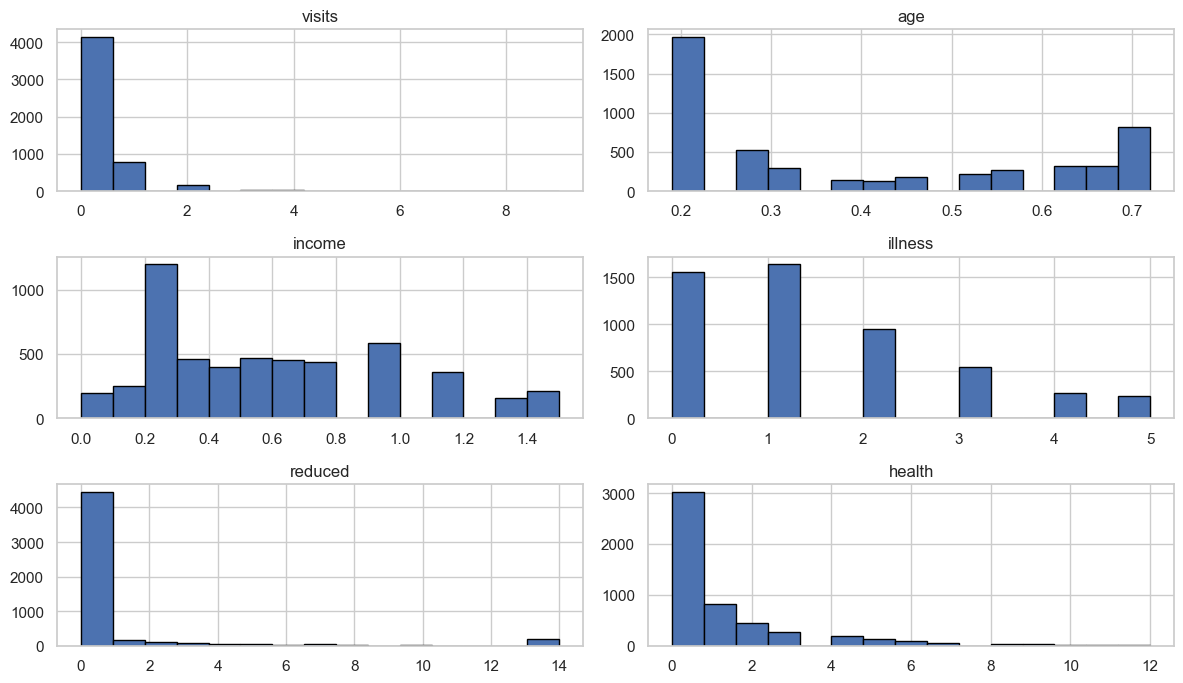

In [52]:
num_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

df[num_cols].hist(figsize=(12, 7), bins=15, edgecolor='black')
plt.tight_layout()
plt.show()

**Q15) Do patients in higher age values visit the doctor more often?**

`age` holds small decimal values (0.19 to 0.72) and the file does not say what unit they are in, so the values are grouped into four bands as they are.

In [53]:
df['Age_Band'] = pd.cut(df['age'], bins=[0, 0.25, 0.45, 0.65, 1.0],
                        labels=['Band 1 (<=0.25)', 'Band 2 (0.26-0.45)', 'Band 3 (0.46-0.65)', 'Band 4 (>0.65)'])

age_summary = df.groupby('Age_Band', observed=True)['visits'].agg(['count', 'mean']).round(3)
age_summary.columns = ['Patients', 'Avg visits']
age_summary

,Patients,Avg visits
Age_Band,,
Band 1 (<=0.25),1965,0.206
Band 2 (0.26-0.45),1096,0.259
Band 3 (0.46-0.65),992,0.365
Band 4 (>0.65),1137,0.454


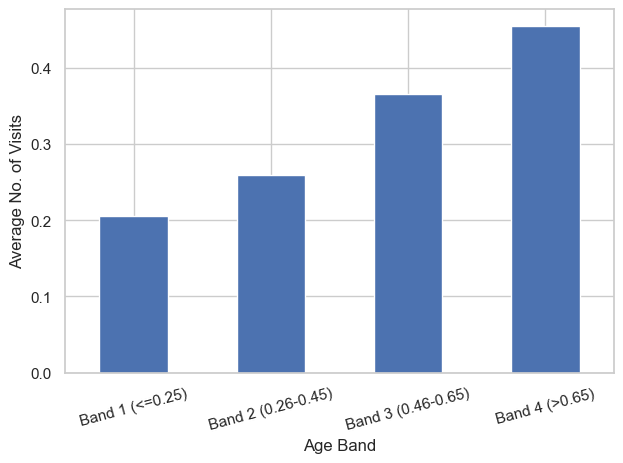

In [54]:
age_summary['Avg visits'].plot(kind='bar')
plt.xlabel("Age Band")
plt.ylabel("Average No. of Visits")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Q16) Do patients with a higher income value visit the doctor more or less often?**

As with `age`, the unit of `income` is not given, so the values are grouped into four bands as they are.

In [55]:
df['Income_Band'] = pd.cut(df['income'], bins=[-0.01, 0.25, 0.55, 0.9, 1.5],
                           labels=['Band 1 (<=0.25)', 'Band 2 (0.26-0.55)', 'Band 3 (0.56-0.90)', 'Band 4 (>0.90)'])

income_summary = df.groupby('Income_Band', observed=True)['visits'].agg(['count', 'mean']).round(3)
income_summary.columns = ['Patients', 'Avg visits']
income_summary

,Patients,Avg visits
Income_Band,,
Band 1 (<=0.25),1638,0.398
Band 2 (0.26-0.55),1329,0.305
Band 3 (0.56-0.90),1485,0.230
Band 4 (>0.90),738,0.225


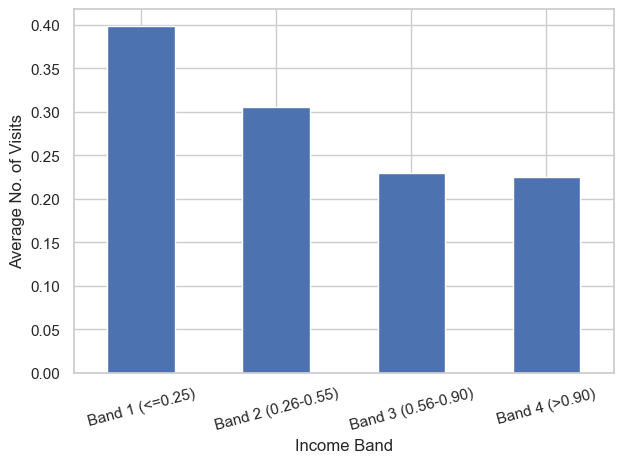

In [56]:
income_summary['Avg visits'].plot(kind='bar')
plt.xlabel("Income Band")
plt.ylabel("Average No. of Visits")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Q17) Do patients with a higher `illness` value make more doctor visits?**

In [57]:
illness_summary = df.groupby('illness')['visits'].agg(['count', 'mean']).round(3)
illness_summary.columns = ['Patients', 'Avg visits']
illness_summary

,Patients,Avg visits
illness,,
0,1554,0.079
1,1638,0.295
2,946,0.404
3,542,0.421
4,274,0.577
5,236,0.814


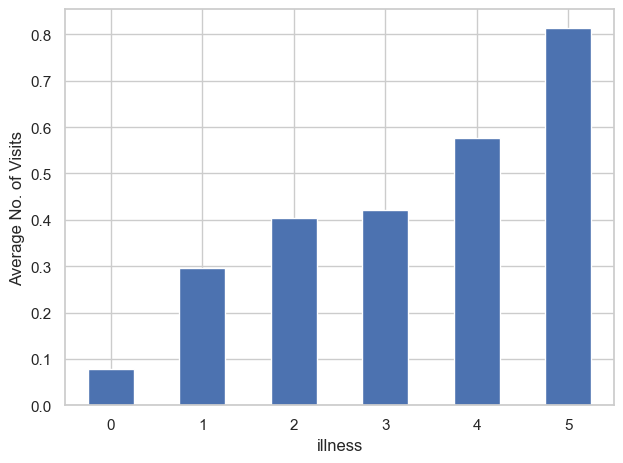

In [58]:
illness_summary['Avg visits'].plot(kind='bar')
plt.xlabel("illness")
plt.ylabel("Average No. of Visits")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Q18) Which numeric columns are most strongly related to the number of visits?**

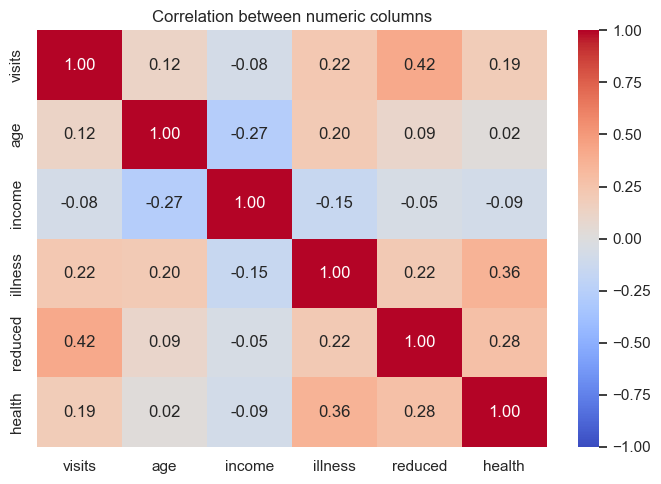

In [59]:
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric columns")
plt.tight_layout()
plt.show()

In [60]:
# Correlation of every numeric column with 'visits', strongest first
corr['visits'].drop('visits').sort_values(ascending=False).round(3)

reduced    0.419
illness    0.224
health     0.193
age        0.125
income    -0.077
Name: visits, dtype: float64

## 6. Key Findings

- **Data quality:** 5,190 records, no missing values. 1,320 rows (25.4%) repeat another row on every data column; they were kept because there is no patient ID and the columns take few distinct values.
- **Most patients did not visit:** 4,141 patients (79.8%) have 0 visits and 1,049 (20.2%) have at least one. Most of those made a single visit (782); the maximum is 9, in just one record.
- **Gender:** 2,702 female and 2,488 male records. Female patients average 0.36 visits against 0.24 for male patients.
- **Chronic flags:** `nchronic` and `lchronic` never occur together. Patients with `lchronic` = yes average 0.60 visits versus 0.26 for the rest, the largest gap among the yes/no columns.
- **Insurance flags:** `freerepat` = yes averages 0.47 visits (vs 0.26) and `freepoor` = yes averages 0.16 (vs 0.31). `private` makes almost no difference (0.30 vs 0.31).
- **Age and income:** average visits rise from 0.21 to 0.45 across the four age bands and fall from 0.40 to 0.23 across the four income bands. Age and income are themselves negatively correlated (-0.27), so these two patterns partly overlap.
- **Illness:** average visits climb steadily with `illness`, from 0.08 at 0 to 0.81 at 5.
- **Strongest link with visits:** `reduced` (correlation 0.42), followed by `illness` (0.22) and `health` (0.19). No single column explains visits on its own.

**Note:** these are associations found in the data, not proof of cause and effect. Visits are heavily concentrated at 0, so averages are small and a few patients with many visits can move them noticeably.